#Inspeção das imagens

In [12]:
import os
import glob

import rasterio
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd

rio = gpd.read_file(
    "../data/raw/shapefiles/rio_tapajos/ana_rio_tapajos.shp"
)

frames = gpd.read_file(
    "../data/raw/geojson/frames_1280_overlay_50pc.geojson"
)

# Mostrar

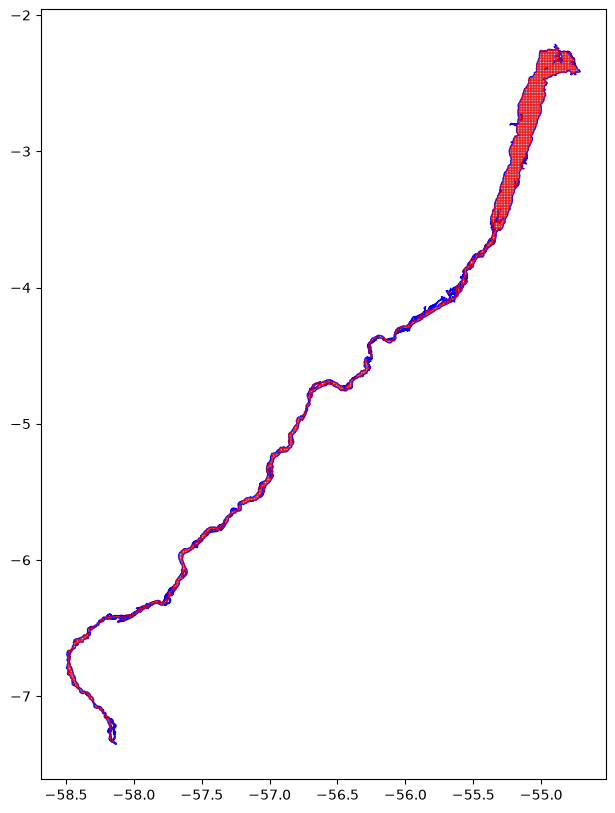

In [13]:
fig, ax = plt.subplots(figsize=(10, 10))

rio.plot(
    ax=ax,
    color="lightblue",
    edgecolor="blue"
)

frames.plot(
    ax=ax,
    facecolor="none",
    edgecolor="red",
    linewidth=0.3
)

plt.show()

# Mostrar apenas o shape 1725

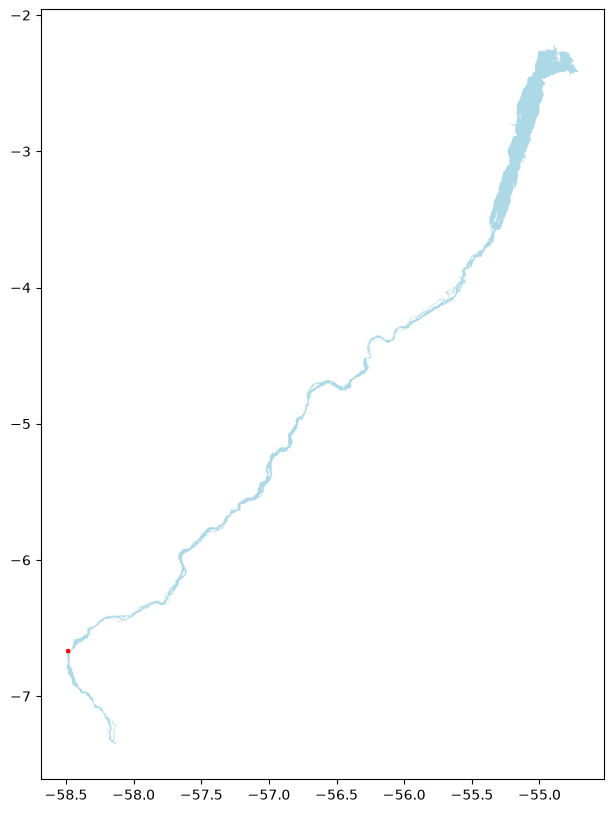

In [15]:
frame = frames[
    frames["id"] == 1725
]

fig, ax = plt.subplots(figsize=(10, 10))

rio.plot(
    ax=ax,
    color="lightblue"
)

frame.plot(
    ax=ax,
    facecolor="none",
    edgecolor="red",
    linewidth=2
)

plt.show()

# Tentando achar um recorte melhor

In [16]:
frames.head()

,id,geometry
0,1725,"POLYGON ((-58.48926 -6.66315, -58.47768 -6.663..."
1,1726,"POLYGON ((-58.48936 -6.67469, -58.47779 -6.674..."
2,1727,"POLYGON ((-58.48947 -6.68623, -58.47789 -6.686..."
3,1728,"POLYGON ((-58.48957 -6.69777, -58.478 -6.69787..."
4,1729,"POLYGON ((-58.48968 -6.70931, -58.4781 -6.7094..."


# Visualizar o frame 1725 com zoom

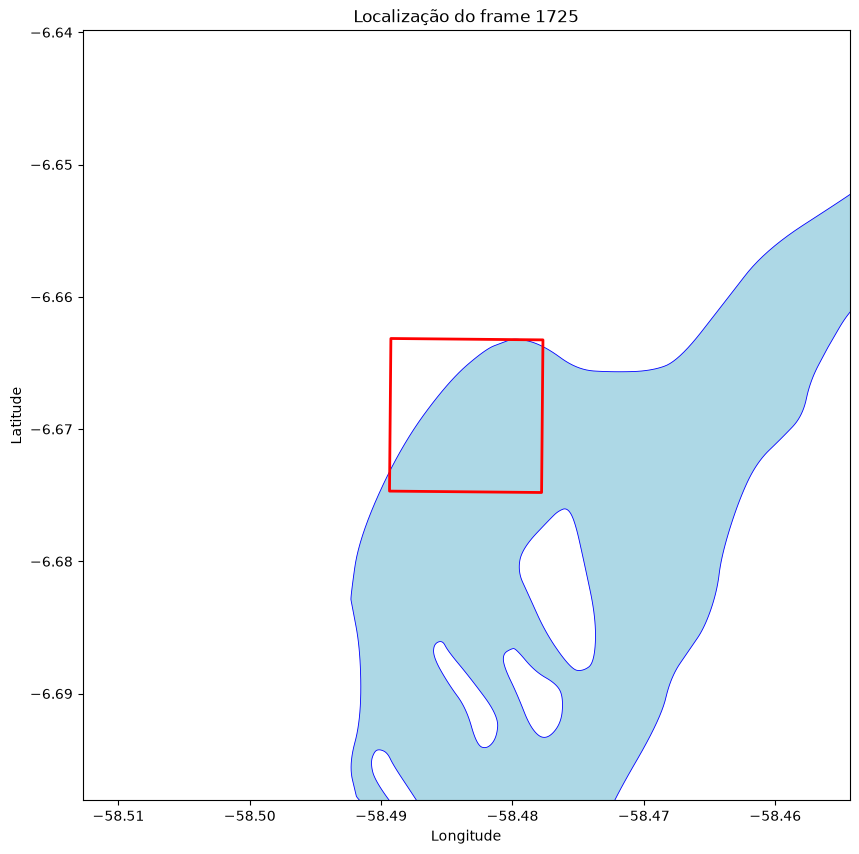

In [17]:
# Seleciona o frame correspondente à imagem 1725.tif
frame_1725 = frames.loc[frames["id"] == 1725].copy()

# Garante que rio e frame estejam no mesmo sistema de coordenadas
frame_1725 = frame_1725.to_crs(rio.crs)

# Limites do frame
minx, miny, maxx, maxy = frame_1725.total_bounds

# Margem visual ao redor do recorte
margem_x = (maxx - minx) * 2
margem_y = (maxy - miny) * 2

fig, ax = plt.subplots(figsize=(10, 10))

rio.plot(
    ax=ax,
    color="lightblue",
    edgecolor="blue",
    linewidth=0.6
)

frame_1725.plot(
    ax=ax,
    facecolor="none",
    edgecolor="red",
    linewidth=2
)

ax.set_xlim(minx - margem_x, maxx + margem_x)
ax.set_ylim(miny - margem_y, maxy + margem_y)

ax.set_title("Localização do frame 1725")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

plt.show()

# Medindo o quanto cada frame está dentro do polígono

In [18]:
# Trabalhar em um CRS projetado, com unidades em metros
rio_utm = rio.to_crs("EPSG:32721")
frames_utm = frames.to_crs("EPSG:32721")

# Junta as partes do rio em uma única geometria
geometria_rio = rio_utm.geometry.union_all()

# Área de cada frame
frames_utm["area_frame"] = frames_utm.geometry.area

# Área de interseção entre cada frame e o rio
frames_utm["area_no_rio"] = frames_utm.geometry.apply(
    lambda geometria: geometria.intersection(geometria_rio).area
)

# Percentual do frame coberto pelo polígono do rio
frames_utm["percentual_rio"] = (
    frames_utm["area_no_rio"]
    / frames_utm["area_frame"]
    * 100
)

frames_utm[
    ["id", "area_frame", "area_no_rio", "percentual_rio"]
].head(10)

,id,area_frame,area_no_rio,percentual_rio
0,1725,1.633214e+06,1.205735e+06,73.825911
1,1726,1.633214e+06,1.546865e+06,94.712919
2,1727,1.633214e+06,1.311436e+06,80.297845
3,1728,1.633215e+06,1.294258e+06,79.246035
4,1729,1.633215e+06,1.323203e+06,81.018293
5,1730,1.633215e+06,1.090601e+06,66.776328
6,1731,1.633215e+06,1.519079e+06,93.011572
7,1732,1.633215e+06,9.436604e+05,57.779313
8,1733,1.633215e+06,1.270180e+06,77.771750
9,1734,1.633215e+06,1.630080e+06,99.808045


In [19]:
frames_selecionados = frames_utm[
    frames_utm["percentual_rio"] >= 20
].copy()

print("Total de frames:", len(frames_utm))
print("Frames selecionados:", len(frames_selecionados))

Total de frames: 2396
Frames selecionados: 2396


# Escolher uma imagem

In [ ]:
imagens = sorted(glob.glob("../data/raw/images/*.tif"))

print(f"{len(imagens)} imagens encontradas")

arquivo = imagens[0]

print(arquivo)

2396 imagens encontradas
../data/raw/images/100080.tif


# Ler as bandas

In [ ]:
with rasterio.open(arquivo) as src:

    B02 = src.read(1)
    B03 = src.read(2)
    B04 = src.read(3)
    B08 = src.read(4)
    B11 = src.read(5)
    B12 = src.read(6)

# Função para normalizar

In [ ]:
def normalizar(img):

    img = img.astype(np.float32)

    minimo = np.nanpercentile(img, 2)
    maximo = np.nanpercentile(img, 98)

    img = np.clip(img, minimo, maximo)

    return (img - minimo) / (maximo - minimo)

# Mostrar várias composições

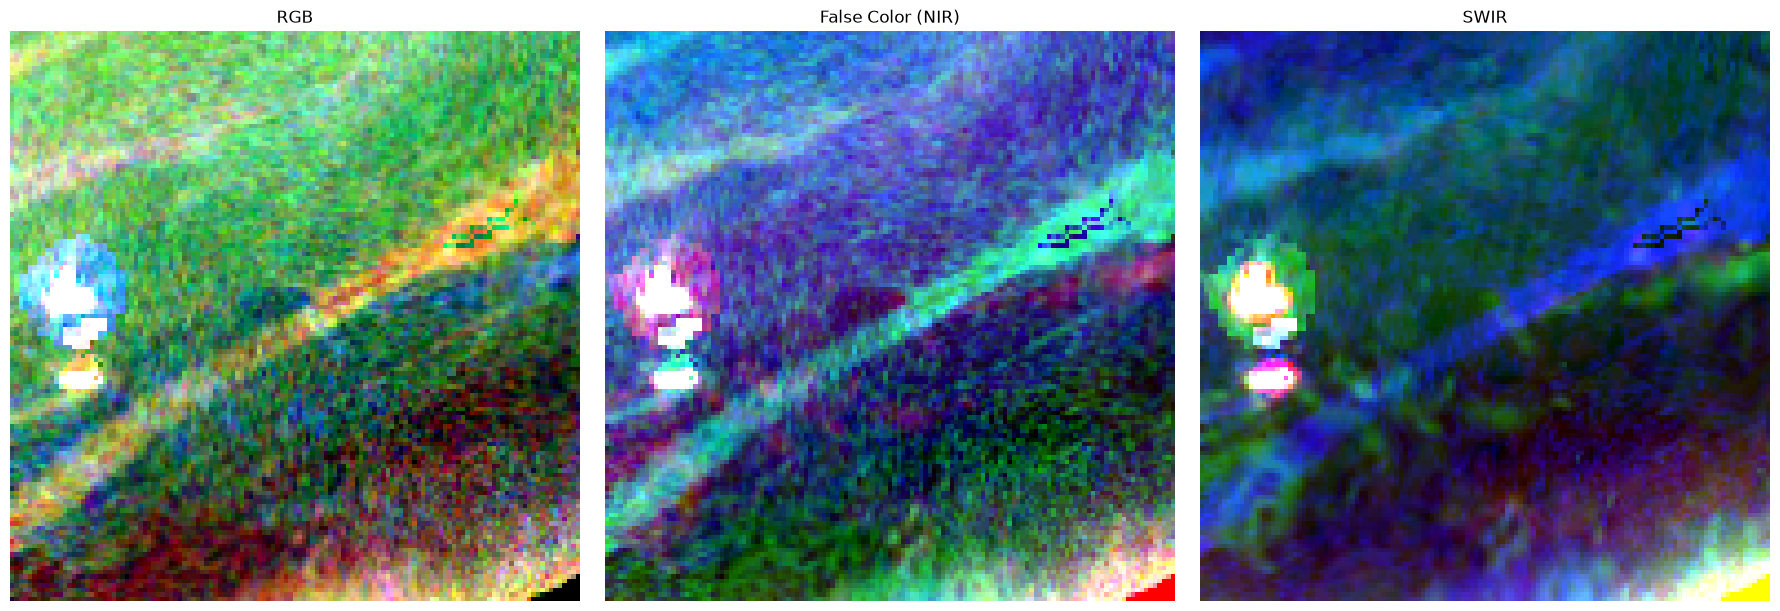

In [ ]:
rgb = np.dstack([
    normalizar(B04),
    normalizar(B03),
    normalizar(B02)
])

false_color = np.dstack([
    normalizar(B08),
    normalizar(B04),
    normalizar(B03)
])

swir = np.dstack([
    normalizar(B11),
    normalizar(B08),
    normalizar(B04)
])

fig, ax = plt.subplots(
    1,
    3,
    figsize=(18,6)
)

ax[0].imshow(rgb)
ax[0].set_title("RGB")

ax[1].imshow(false_color)
ax[1].set_title("False Color (NIR)")

ax[2].imshow(swir)
ax[2].set_title("SWIR")

for a in ax:
    a.axis("off")

plt.tight_layout()
plt.show()

# Bandas individuais em tom de cinza


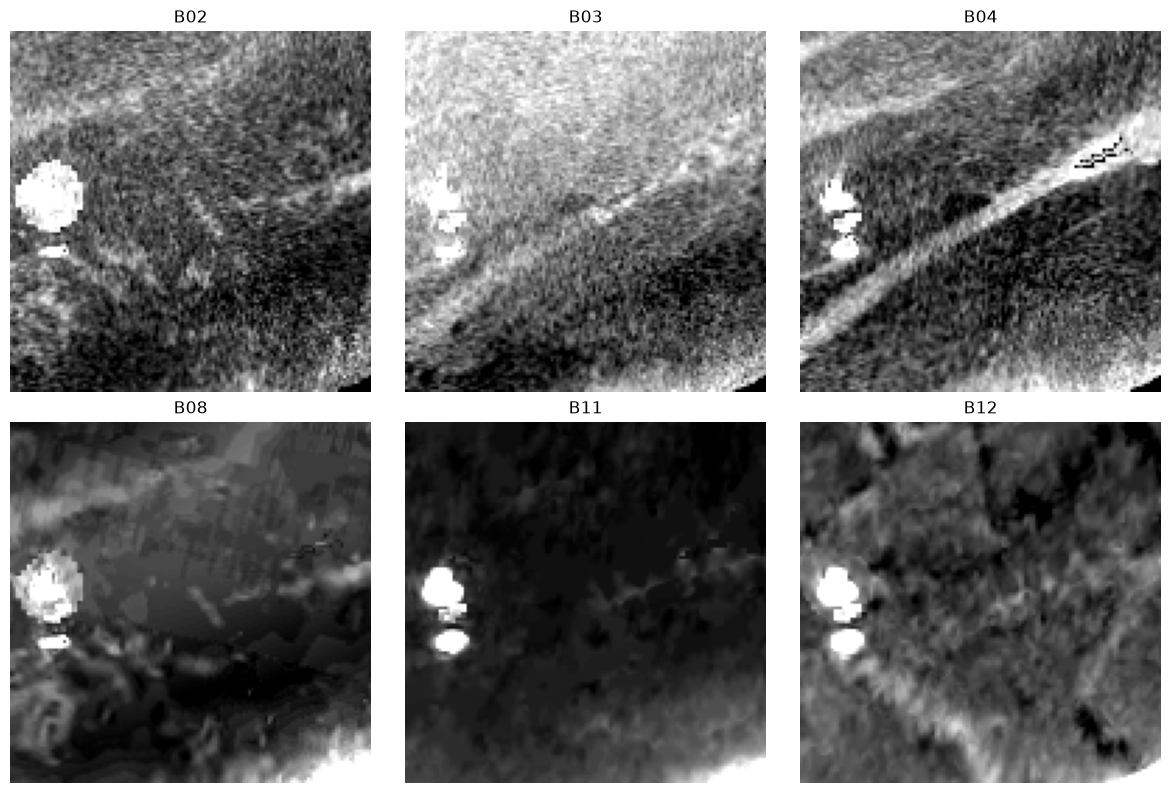

In [ ]:
fig, ax = plt.subplots(2, 3, figsize=(12, 8))

bandas = [B02, B03, B04, B08, B11, B12]
nomes = ["B02", "B03", "B04", "B08", "B11", "B12"]

for eixo, banda, nome in zip(ax.ravel(), bandas, nomes):
    eixo.imshow(normalizar(banda), cmap="gray")
    eixo.set_title(nome)
    eixo.axis("off")

plt.tight_layout()

# Distribuição de frames

In [20]:
frames_utm["percentual_rio"].describe(
    percentiles=[0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95]
)

count    2396.000000
mean       90.353141
std        14.560963
min        50.211950
5%         57.606702
10%        64.606524
25%        82.038016
50%       100.000000
75%       100.000000
90%       100.000000
95%       100.000000
max       100.000000
Name: percentual_rio, dtype: float64

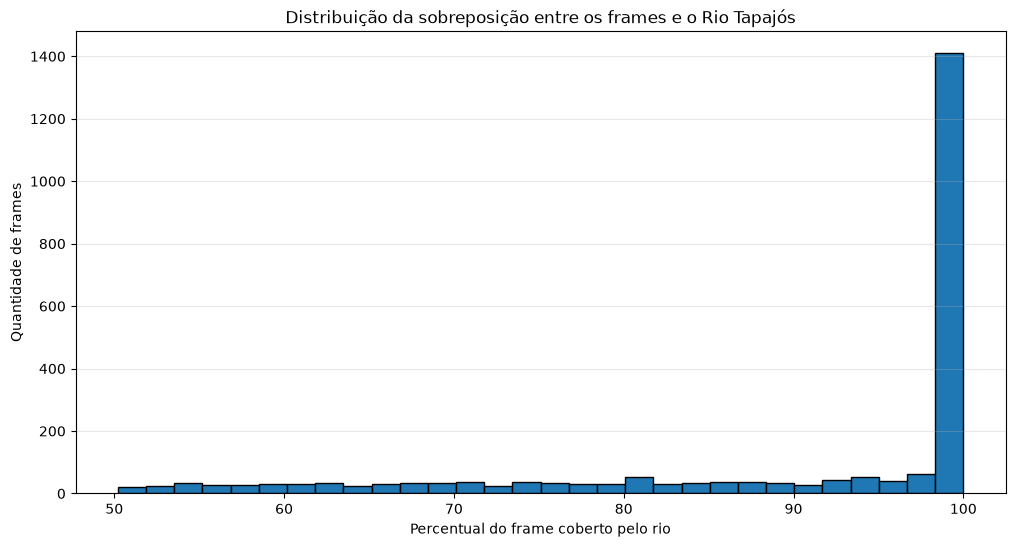

In [21]:
plt.figure(figsize=(12, 6))

plt.hist(
    frames_utm["percentual_rio"],
    bins=30,
    edgecolor="black"
)

plt.xlabel("Percentual do frame coberto pelo rio")
plt.ylabel("Quantidade de frames")
plt.title("Distribuição da sobreposição entre os frames e o Rio Tapajós")

plt.grid(axis="y", alpha=0.3)
plt.show()

In [22]:
frames_candidatos = frames_utm[
    frames_utm["percentual_rio"].between(40, 95)
].copy()

print("Total de frames:", len(frames_utm))
print("Frames candidatos:", len(frames_candidatos))

Total de frames: 2396
Frames candidatos: 884


In [23]:
frames_candidatos["possui_banco"] = ""
frames_candidatos["qualidade"] = ""
frames_candidatos["usar_dataset"] = ""
frames_candidatos["observacao"] = ""

frames_candidatos[
    [
        "id",
        "percentual_rio",
        "possui_banco",
        "qualidade",
        "usar_dataset",
        "observacao"
    ]
].head()

,id,percentual_rio,possui_banco,qualidade,usar_dataset,observacao
0,1725,73.825911,,,,
1,1726,94.712919,,,,
2,1727,80.297845,,,,
3,1728,79.246035,,,,
4,1729,81.018293,,,,
